# Week 4, Part 1
## Intro to Feature Selection, Multicollinearity, Categorical Predictors

Two datasets:

1. **Palmer penguins** — picking up the unresolved model from Week 3.
2. **Bike rentals** (UCI Bike Sharing, daily) — the same problems, much louder.

Topics: multicollinearity and VIF, categorical predictors

## Multicollinearity

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

# Hello again Penguins 
peng = pd.read_csv("../data/penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)

print(f"n = {len(peng)}")
peng.head()

n = 342


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [2]:
# At the end of last week, we built a model predicting body mass with bill length, bill depth, and flipper length

# Note that the syntax below is using a different api than previously, but it gives the same result
full = smf.ols("body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm", data=peng).fit()
print(full.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        11:26:41   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6424.7647    561.46

In [3]:
# As we saw last week, this model is overwhelmingly significant based on the F-statistic,
# but the individual t-statistics for the additional predictors are not significant. 

# Let's remind ourselves of the correlation matrices
peng[["flipper_length_mm", "bill_length_mm", "bill_depth_mm", "body_mass_g"]].corr()

,flipper_length_mm,bill_length_mm,bill_depth_mm,body_mass_g
flipper_length_mm,1.000000,0.656181,-0.583851,0.871202
bill_length_mm,0.656181,1.000000,-0.235053,0.595110
bill_depth_mm,-0.583851,-0.235053,1.000000,-0.471916
body_mass_g,0.871202,0.595110,-0.471916,1.000000


corr(flipper_length_mm, bill_length_mm) = 0.6562
corr(flipper_length_mm, bill_depth_mm) = -0.5839
corr(bill_length_mm, bill_depth_mm) = -0.2351


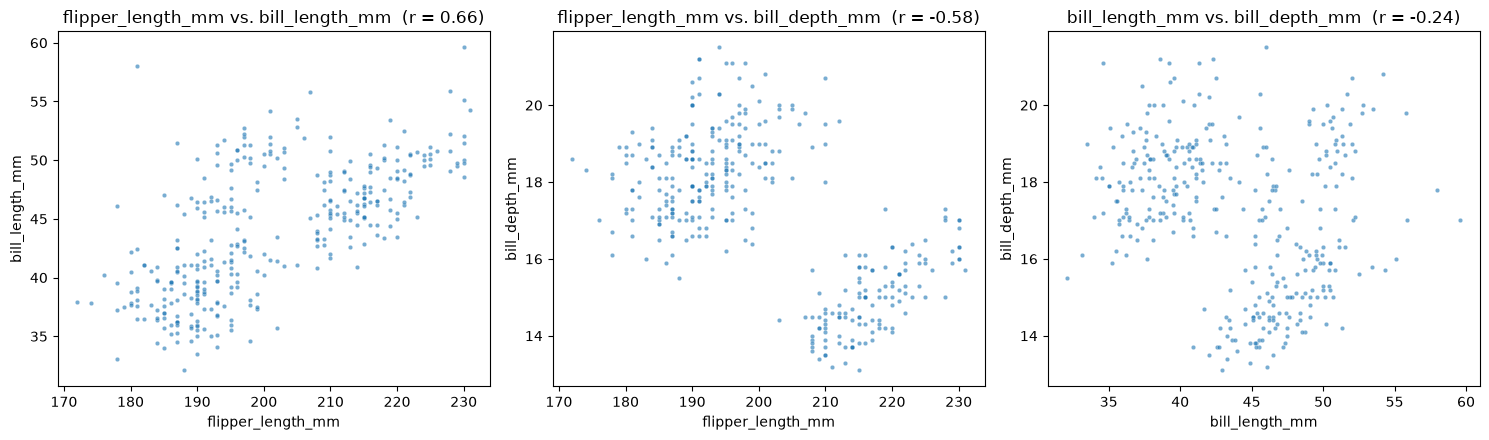

In [4]:
# Pairwise correlations among the three penguin size measurements.
pairs = [
    ("flipper_length_mm", "bill_length_mm"),
    ("flipper_length_mm", "bill_depth_mm"),
    ("bill_length_mm", "bill_depth_mm"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (x, y) in zip(axes, pairs):
    r = peng[x].corr(peng[y])
    print(f"corr({x}, {y}) = {r:.4f}")
    sns.scatterplot(data=peng, x=x, y=y, s=10, alpha=0.6, ax=ax)
    ax.set_title(f"{x} vs. {y}  (r = {r:.2f})")
plt.tight_layout()

In [5]:
# Now let's calculate the Varince Inflation Factor for each of these regressors
# What does this tell us? 

preds = ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
def vif_table(df, cols):
    X = sm.add_constant(df[cols])
    return pd.DataFrame({
        "variable": cols,
        "VIF": [variance_inflation_factor(X.values, X.columns.get_loc(c)) for c in cols],
    }).round(2)

vif_table(peng, preds)

,variable,VIF
0,flipper_length_mm,2.67
1,bill_length_mm,1.87
2,bill_depth_mm,1.61


In [6]:
# We are now going to look at this with a different dataset (Hooray!)
# The bikesharing dataset is used by Christoph Molnar in his book Interpretable Machine Learning
# https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset for definitions
# Goal for regression: predict number of bike rentals (cnt) based on season, weather, etc. 

bike = pd.read_csv("../data/bike-sharing-daily.csv", parse_dates=["dteday"])
print(bike.shape)
print(bike.dtypes)
bike.head()

(731, 16)
instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


corr(temp, atemp) = 0.9917


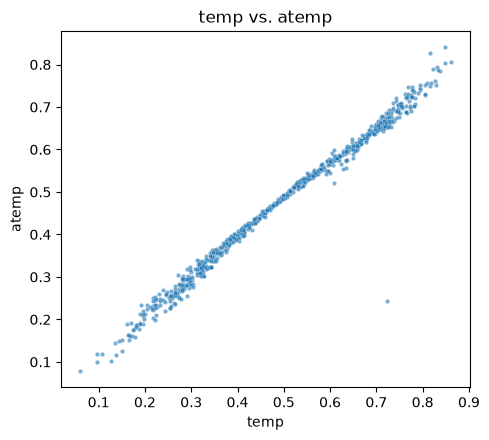

In [7]:
# Temp is the actual temparature (normalized, in celsius)
# Atemp is the "feels like" temperature (normalized, in celsius)
# We would expect these variables to be highly correlated. 
# Let's calculate their correlation and plot them to see. 

print(f"corr(temp, atemp) = {bike['temp'].corr(bike['atemp']):.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.scatterplot(data=bike, x="temp", y="atemp", s=10, alpha=0.6, ax=ax)
ax.set_title("temp vs. atemp")
plt.tight_layout()

In [8]:
# Now let's build a model to predict count, 
# First, we'll build with just temp, then then with temp and atemp. 
# Let's pay particularly close attention to standard errors.

one  = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()
both = smf.ols("cnt ~ temp + atemp + hum + windspeed", data=bike).fit()

comp = pd.DataFrame({
    "temp only":  {"coef(temp)": one.params["temp"],  "SE(temp)": one.bse["temp"],
                   "t(temp)": one.tvalues["temp"], "R^2": one.rsquared, "Adj. R^2": one.rsquared_adj},
    "temp+atemp": {"coef(temp)": both.params["temp"], "SE(temp)": both.bse["temp"],
                   "t(temp)": both.tvalues["temp"], "R^2": both.rsquared, "Adj. R^2": both.rsquared_adj},
}).T
print(comp.round(3))

print("\nwith both:")
print(both.summary().tables[1])
print("\nVIF:")
print(vif_table(bike, ["temp", "atemp", "hum", "windspeed"]))

            coef(temp)  SE(temp)  t(temp)    R^2  Adj. R^2
temp only     6625.533   293.085   22.606  0.461     0.459
temp+atemp    2111.814  2282.198    0.925  0.464     0.461

with both:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3860.3685    355.389     10.862      0.000    3162.656    4558.081
temp        2111.8136   2282.198      0.925      0.355   -2368.681    6592.308
atemp       5139.1524   2576.997      1.994      0.046      79.896    1.02e+04
hum        -3149.1098    383.994     -8.201      0.000   -3902.982   -2395.238
windspeed  -4528.6748    721.085     -6.280      0.000   -5944.336   -3113.013

VIF:
    variable    VIF
0       temp  62.97
1      atemp  63.63
2        hum   1.08
3  windspeed   1.13


      temp (alone)  temp (w/ atemp)
mean        6620.3           -960.4
std          293.8           6520.6
min         5523.6         -22280.4
max         7757.9           8515.1


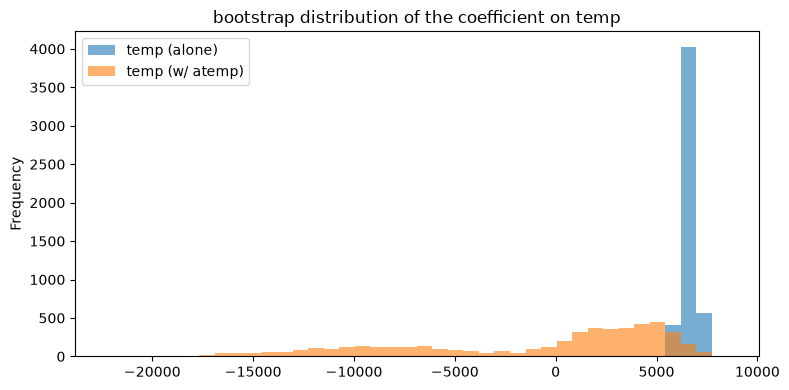

In [9]:
# Let's do a bootstrap simulation to see the variance in the coefficient for temperature

rng = np.random.default_rng(42)
rows = []
for _ in range(5000): # Only doing 5000 for the sake of time, since this dataset is larger
    s = bike.sample(len(bike), replace=True, random_state=int(rng.integers(1e6)))
    rows.append({
        "temp (alone)":     smf.ols("cnt ~ temp + hum + windspeed", data=s).fit().params["temp"],
        "temp (w/ atemp)":  smf.ols("cnt ~ temp + atemp + hum + windspeed", data=s).fit().params["temp"],
    })
boot = pd.DataFrame(rows)
print(boot.describe().round(1).loc[["mean", "std", "min", "max"]])

boot.plot(kind="hist", bins=40, alpha=0.6, figsize=(8, 4),
          title="bootstrap distribution of the coefficient on temp")
plt.tight_layout()

      temp (alone)  temp (w/ atemp)
mean       -4806.1          -4359.6
std          679.4            780.5
min        -7086.6          -7090.4
max        -2033.4          -1492.4


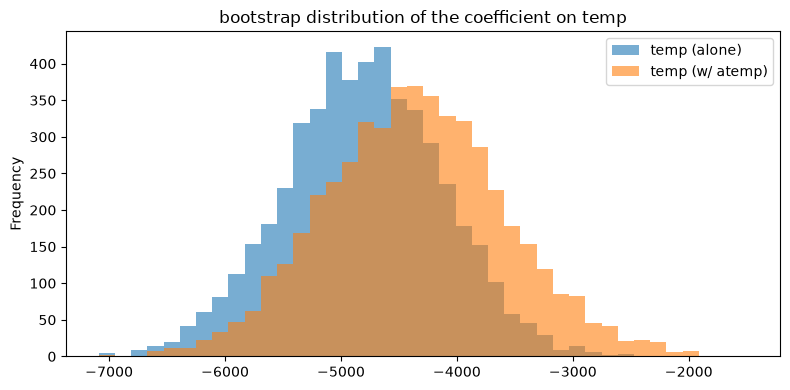

In [10]:
# We can do the same thing for the other coefficients as well if we want to
rng = np.random.default_rng(4)
rows = []
for _ in range(5000): # Only doing 5000 for the sake of time, since this dataset is larger
    s = bike.sample(len(bike), replace=True, random_state=int(rng.integers(1e6)))
    rows.append({
        "temp (alone)":     smf.ols("cnt ~ temp + hum + windspeed", data=s).fit().params["windspeed"],
        "temp (w/ atemp)":  smf.ols("cnt ~ temp + atemp + hum + windspeed", data=s).fit().params["windspeed"],
    })
boot = pd.DataFrame(rows)
print(boot.describe().round(1).loc[["mean", "std", "min", "max"]])

boot.plot(kind="hist", bins=40, alpha=0.6, figsize=(8, 4),
          title="bootstrap distribution of the coefficient on temp")
plt.tight_layout()

## Categorical Variables

In [11]:
# k levels -> k-1 dummies. The omitted level is the reference.
# Now we are looking at flipper_length AND species

m_species = smf.ols("body_mass_g ~ flipper_length_mm + C(species)", data=peng).fit()
print(m_species.summary().tables[1])
print("\nreference level:", sorted(peng.species.unique())[0])

                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -4031.4769    584.151     -6.901      0.000   -5180.507   -2882.447
C(species)[T.Chinstrap]  -206.5101     57.731     -3.577      0.000    -320.067     -92.954
C(species)[T.Gentoo]      266.8096     95.264      2.801      0.005      79.425     454.194
flipper_length_mm          40.7054      3.071     13.255      0.000      34.665      46.746

reference level: Adelie


What does this tell us: 

* Adelie: mass = −4031 + 40.7·flipper
* Chinstrap: mass = (−4031 − 206.5) + 40.7·flipper
* Gentoo: mass = (−4031 + 266.8) + 40.7·flipper

At the same flipper length (e.g. holding flipper length fixed), Chinstraps weigh about 207g less than Adelies on average

At the same flipper length, Gentoos weigh about 267g more than Adelies on average

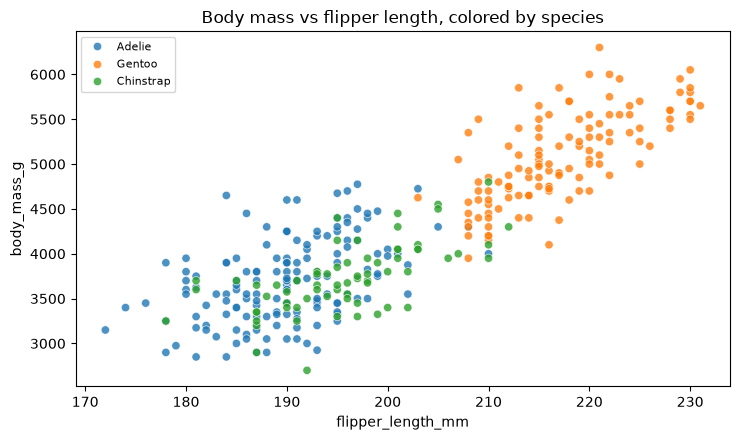

In [12]:
# Let's also plot this, per usual

plt.figure(figsize=(7.5, 4.5))
ax = sns.scatterplot(data=peng, x="flipper_length_mm", y="body_mass_g",
                     hue="species", alpha=0.8)
ax.set_title("Body mass vs flipper length, colored by species")
ax.legend(fontsize=8)
plt.tight_layout()

In [13]:
# We can also change the reference level 

alt = smf.ols('body_mass_g ~ flipper_length_mm + C(species, Treatment(reference="Gentoo"))',
              data=peng).fit()
print(alt.summary().tables[1])

print(f"\nR^2:            {m_species.rsquared:.10f}  vs  {alt.rsquared:.10f}")
print(f"max |fitted difference|: {np.abs(m_species.fittedvalues - alt.fittedvalues).max():.10f}")

                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                              -3764.6673    667.844     -5.637      0.000   -5078.322   -2451.012
C(species, Treatment(reference="Gentoo"))[T.Adelie]     -266.8096     95.264     -2.801      0.005    -454.194     -79.425
C(species, Treatment(reference="Gentoo"))[T.Chinstrap]  -473.3197     86.746     -5.456      0.000    -643.949    -302.690
flipper_length_mm                                         40.7054      3.071     13.255      0.000      34.665      46.746

R^2:            0.7826479016  vs  0.7826479016
max |fitted difference|: 0.0000000004


In [14]:
# Let's also look again at the bike data. 
# We have to be careful for numbers that we want to encode as categories

# The trap: season is coded 1,2,3,4. pandas sees numbers.

as_number = smf.ols("cnt ~ season + temp", data=bike).fit()
as_factor = smf.ols("cnt ~ C(season) + temp", data=bike).fit()

print("season as a NUMBER (1 coefficient, assumes equal spacing and an order):")
print(as_number.summary().tables[1])
print("\nseason as a FACTOR (3 coefficients):")
print(as_factor.summary().tables[1])
print(f"\nadj R^2: numeric {as_number.rsquared_adj:.4f}   factor {as_factor.rsquared_adj:.4f}")

season as a NUMBER (1 coefficient, assumes equal spacing and an order):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    639.7020    173.314      3.691      0.000     299.447     979.957
season       385.4564     51.453      7.491      0.000     284.443     486.470
temp        5858.7266    312.231     18.764      0.000    5245.746    6471.707

season as a FACTOR (3 coefficients):
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        745.7873    187.476      3.978      0.000     377.728    1113.847
C(season)[T.2]   848.7236    197.082      4.306      0.000     461.806    1235.642
C(season)[T.3]   490.1956    259.006      1.893      0.059     -18.294     998.685
C(season)[T.4]  1342.8730    164.588      8.159      0.000    1019.748    1665.9

### One Hot Encoding

In [15]:
# Build all three parameterizations by hand.

onehot = pd.get_dummies(peng.species, dtype=float)              # k columns
dummy  = pd.get_dummies(peng.species, drop_first=True, dtype=float)  # k-1 columns

print("one-hot columns:", list(onehot.columns))
print("dummy columns:  ", list(dummy.columns))

one-hot columns: ['Adelie', 'Chinstrap', 'Gentoo']
dummy columns:   ['Chinstrap', 'Gentoo']


In [16]:
# (a) dummy + intercept   (b) one-hot, NO intercept   (c) one-hot + intercept = the trap

a = sm.OLS(peng.body_mass_g, sm.add_constant(dummy)).fit()
b = sm.OLS(peng.body_mass_g, onehot).fit()
c = sm.OLS(peng.body_mass_g, sm.add_constant(onehot)).fit()

for name, m, X_ in [("(a) dummy + intercept", a, sm.add_constant(dummy)),
                    ("(b) one-hot, no intercept", b, onehot),
                    ("(c) one-hot + intercept", c, sm.add_constant(onehot))]:
    print(f"{name:28s} cols {X_.shape[1]}  rank {np.linalg.matrix_rank(X_.values)}"
          f"   RSS {m.ssr:,.1f}")

(a) dummy + intercept        cols 3  rank 3   RSS 72,443,483.2
(b) one-hot, no intercept    cols 3  rank 3   RSS 72,443,483.2
(c) one-hot + intercept      cols 4  rank 3   RSS 72,443,483.2


In [17]:
# (a) and (b) are the SAME MODEL, reparameterized. Identical fit, different coefficients.

print(f"max |fitted difference|, (a) vs (b): "
      f"{np.abs(a.fittedvalues - b.fittedvalues).max():.10f}\n")

print("(a) coefficients are DIFFERENCES from the reference level (Adelie):")
print(a.params.round(2).to_string())

print("\n(b) coefficients ARE the group means:")
print(b.params.round(2).to_string())
print("\nactual group means:")
print(peng.groupby("species").body_mass_g.mean().round(2).to_string())

max |fitted difference|, (a) vs (b): 0.0000000000

(a) coefficients are DIFFERENCES from the reference level (Adelie):
const        3700.66
Chinstrap      32.43
Gentoo       1375.35

(b) coefficients ARE the group means:
Adelie       3700.66
Chinstrap    3733.09
Gentoo       5076.02

actual group means:
species
Adelie       3700.66
Chinstrap    3733.09
Gentoo       5076.02
